In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import scipy
import os
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.models import load_model
# from tensorflow.keras.layers import Dense, Input
# import tensorflow_addons as tfa


In [2]:
import sys
sys.version

'3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]'

`'3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]'`

# Carga de datos

## Datos B/manga (Colombia)

In [3]:

# URL base de la API
base_url_ws_col = "https://www.datos.gov.co/resource/57ur-5p28.csv"

# Parámetros
limit = 1000  # número máximo permitido por la API
offset = 0    # desplazamiento inicial
all_data = [] # lista para almacenar los bloques

csv_file_ws_col = "..\\data\\datos_eh_bcmga_2021.csv"


In [4]:
if os.path.exists(csv_file_ws_col):
    ws_col = pd.read_csv(csv_file_ws_col)
    print("Se carga el archivo csv")
else:
    while True:
        # Construir URL con paginación
        url = f"{base_url_ws_col}?$limit={limit}&$offset={offset}"
        print(f"Descargando: {url}")

        # Hacer la solicitud
        response = requests.get(url)
        
        # Si falla la solicitud, salir
        if response.status_code != 200:
            print(f"Error en la descarga: {response.status_code}")
            break

        # Leer el bloque como DataFrame
        df_chunk = pd.read_csv(StringIO(response.text))
        
        # Si el bloque está vacío, terminamos
        if df_chunk.empty:
            break
        
        # Agregar a la lista
        all_data.append(df_chunk)
        
        # Aumentar el offset para el siguiente bloque
        offset += limit
    # Unir todos los bloques en un solo DataFrame
    ws_col = pd.concat(all_data, ignore_index=True)

    print(f"Total de registros descargados: {len(ws_col)}")

    ws_col.to_csv(csv_file_ws_col, index=False)


Se carga el archivo csv


## Datos Bruselas (Belgica)

In [5]:
url_bel = "https://zenodo.org/records/10723261/files/Weather_data.mat"
mat_file_ws_bel = "..\\data\\Weather_data.mat"

In [6]:
if os.path.exists(mat_file_ws_bel):
    ws_bel = scipy.io.loadmat(mat_file_ws_bel)
    print("Se carga el archivo mat")

else:

    response = requests.get(url_bel)
    # Verificar que la descarga fue exitosa
    if response.status_code == 200:
        with open(mat_file_ws_bel, "wb") as f:
            f.write(response.content)
        print(f"Archivo guardado como: {mat_file_ws_bel}")
        ws_bel = scipy.io.loadmat(mat_file_ws_bel)
        print("Se carga el archivo mat")
    else:
        print(f"Error al descargar: {response.status_code}")

Se carga el archivo mat


In [7]:
# # Extract data from dataset

# WS_data = scipy.io.loadmat(mat_file_ws_bel)
# WS_data.keys()

# Preprocesamiento

## Datos B/manga

In [8]:
# Copia del df original
df_col = ws_col.copy()

In [9]:
df_col.head()

,estaci_n,tipo,coordenada_x,coordenada_y,date,time,out,hum,speed,dir,bar,rain,rad,index
0,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T00:00:00.000,22.1,98.0,0.0,SE,676.0,0.0,0.0,-999.0
1,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T01:00:00.000,20.3,96.0,0.4,SE,676.2,5.2,0.0,-999.0
2,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T02:00:00.000,20.1,99.0,0.4,WSW,675.8,25.6,0.0,-999.0
3,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T03:00:00.000,19.6,99.0,0.4,SSE,675.6,6.0,0.0,-999.0
4,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T04:00:00.000,19.8,99.0,0.0,SSE,675.9,0.2,0.0,-999.0


En la columna `dir` se cambia los valores cardinales a grados

In [10]:
cardinal_to_deg = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5
}


In [11]:

# Normalizar a string para detectar cardinales
df_col['dir'] = df_col['dir'].astype(str).str.strip().str.upper()

# Convertir cardinales a grados
df_col['dir_deg'] = df_col['dir'].map(cardinal_to_deg)

# Si no es cardinal, intentar convertir a número
df_col['dir_deg'] = df_col['dir_deg'].fillna(pd.to_numeric(df_col['dir'], errors='coerce'))

# Reemplazar valores inválidos
df_col['dir_deg'] = df_col['dir_deg'].replace([-999, -999.0], np.nan)

# Si hay valores > 360, llevarlos al rango [0,360)
df_col['dir_deg'] = df_col['dir_deg'] % 360

Se arregla la columna `bar` que indica la presión registrada

In [12]:
# Reemplazar valores inválidos
df_col['bar'] = df_col['bar'].replace([-999, -999.0], np.nan)

Se arregla la columna `speed` que indica la velocidad del viento registrada

In [13]:
(df_col["speed"].value_counts() / df_col.shape[0]).apply(lambda a: f"{100 * a:.2f} %")

speed
 0.000      32.23 %
-999.000    17.57 %
 0.400      11.99 %
 0.900       6.94 %
 1.300       4.53 %
             ...   
 2.425       0.00 %
 2.009       0.00 %
 1.736       0.00 %
 3.304       0.00 %
 1.786       0.00 %
Name: count, Length: 874, dtype: object

Se toma las columnas `date` y `time` para ser combinadas y obtener la columnas `datetime`

In [14]:
# Supongamos que df_col tiene las columnas 'date' y 'time'
df_col['date'] = pd.to_datetime(df_col['date'])
df_col['time'] = pd.to_datetime(df_col['time']).dt.time  # extraer solo la hora

# Combinar
df_col['datetime'] = df_col.apply(lambda row: pd.Timestamp.combine(row['date'], row['time']), axis=1)


Se elimnan los valores `nan` del dataframe

In [15]:
df_col.shape

(138566, 16)

In [16]:
df_col = df_col.loc[
    ~ df_col["dir_deg"].isna() &
    ~ df_col["bar"].isna()
].copy()

df_col.shape

(77664, 16)

In [17]:
f"Se conserva un totla de {100 * df_col.shape[0] / ws_col.shape[0]:.2f}% de los datos originales"

'Se conserva un totla de 56.05% de los datos originales'

In [18]:
df_col.head()

,estaci_n,tipo,coordenada_x,coordenada_y,date,time,out,hum,speed,dir,bar,rain,rad,index,dir_deg,datetime
0,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,00:00:00,22.1,98.0,0.0,SE,676.0,0.0,0.0,-999.0,135.0,2021-06-01 00:00:00
1,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,01:00:00,20.3,96.0,0.4,SE,676.2,5.2,0.0,-999.0,135.0,2021-06-01 01:00:00
2,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,02:00:00,20.1,99.0,0.4,WSW,675.8,25.6,0.0,-999.0,247.5,2021-06-01 02:00:00
3,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,03:00:00,19.6,99.0,0.4,SSE,675.6,6.0,0.0,-999.0,157.5,2021-06-01 03:00:00
4,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,04:00:00,19.8,99.0,0.0,SSE,675.9,0.2,0.0,-999.0,157.5,2021-06-01 04:00:00


In [19]:
fechas , conteo = np.unique(df_col["datetime"], return_counts=True)

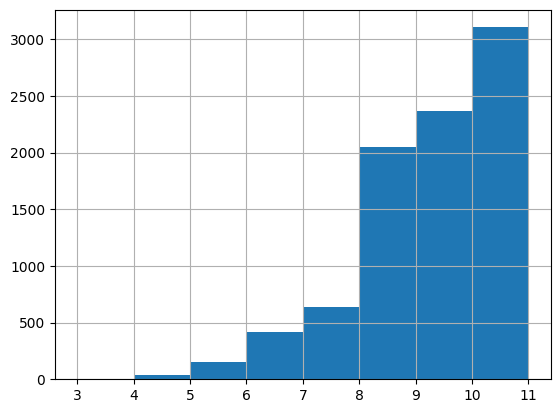

In [20]:
plt.hist(conteo, bins=len(np.unique(conteo))- 1)
plt.grid()
plt.show()

Se necesita que las estaciones tengas la misma cantidad y los mismo registros de fecha

In [21]:
top_fechas = (df_col["datetime"].value_counts()[df_col["datetime"].value_counts() >= 9].index)

In [22]:
df_cln = df_col[df_col["datetime"].isin(top_fechas)].copy()

In [23]:
df_col.shape , df_cln.shape

((77664, 16), (53425, 16))

In [24]:
df_cln = df_cln.sort_values("datetime").reset_index(drop=True)

In [25]:
df_cln["datetime"].diff().value_counts().head()

datetime
0 days 00:00:00    47955
0 days 01:00:00     5306
0 days 02:00:00       41
0 days 17:00:00       17
0 days 16:00:00       16
Name: count, dtype: int64

In [26]:
df_cln["datetime"].diff().sample(5)

34602   0 days
7375    0 days
30667   0 days
52110   0 days
31552   0 days
Name: datetime, dtype: timedelta64[ns]

In [27]:
idx = 22801
count = 1
grupos_fechas = dict()
delta_tiempo = df_cln.loc[[idx, idx + 1], "datetime"].diff()[idx + 1]
delta_tiempo

Timedelta('0 days 03:00:00')

In [28]:
df_cln.loc[[22801, 22802, 22803], "datetime"].diff()
df_cln.loc[[22801, 22802, 22803], "datetime"]

22801   2021-06-14 06:00:00
22802   2021-06-14 09:00:00
22803   2021-06-14 09:00:00
Name: datetime, dtype: datetime64[ns]

In [29]:
# for idx in [22800, 22801, 22802, 22803]:
grupos_fechas = dict()
count = 1
for idx in range(df_cln.shape[0] - 1):
    # print("#"*20)
    # print(idx)
    # print(grupos_fechas)
    if not f"grupo_{count}" in grupos_fechas: grupos_fechas[f"grupo_{count}"] = list()
    # print(grupos_fechas)
    delta_tiempo = df_cln.loc[[idx, idx + 1], "datetime"].diff()[idx + 1]
    # print(delta_tiempo)
    if delta_tiempo in [dt.timedelta(hours=0), dt.timedelta(hours=1)]:
        # print("A")
        grupos_fechas[f"grupo_{count}"].append(idx + 1)
    else:
        # print("B")
        count += 1
        grupos_fechas[f"grupo_{count}"] = [idx + 1]
    ...

In [30]:
len(grupos_fechas)

164

In [31]:
df_cln.loc[grupos_fechas["grupo_67"], "datetime"].unique()#.diff().value_counts()

<DatetimeArray>
['2021-06-30 12:00:00', '2021-06-30 13:00:00', '2021-06-30 14:00:00',
 '2021-06-30 15:00:00', '2021-06-30 16:00:00', '2021-06-30 17:00:00',
 '2021-06-30 18:00:00', '2021-06-30 19:00:00', '2021-06-30 20:00:00',
 '2021-06-30 21:00:00',
 ...
 '2021-07-31 14:00:00', '2021-07-31 15:00:00', '2021-07-31 16:00:00',
 '2021-07-31 17:00:00', '2021-07-31 18:00:00', '2021-07-31 19:00:00',
 '2021-07-31 20:00:00', '2021-07-31 21:00:00', '2021-07-31 22:00:00',
 '2021-07-31 23:00:00']
Length: 756, dtype: datetime64[ns]

In [32]:
df_cln.loc[grupos_fechas["grupo_67"], "datetime"].value_counts()

datetime
2021-07-29 10:00:00    11
2021-07-29 09:00:00    11
2021-07-29 08:00:00    11
2021-07-29 07:00:00    11
2021-07-29 06:00:00    11
                       ..
2021-07-08 01:00:00     9
2021-07-11 07:00:00     9
2021-07-12 09:00:00     9
2021-07-12 08:00:00     9
2021-07-11 08:00:00     9
Name: count, Length: 756, dtype: int64

In [33]:
df_cln.loc[grupos_fechas["grupo_67"], "datetime"].diff().value_counts()

datetime
0 days 00:00:00    7330
0 days 01:00:00     755
Name: count, dtype: int64

In [34]:
1+1

2

In [35]:
grupos_fechas_largo = {k: len(l) for k, l in grupos_fechas.items()}
grupo_mas_largo = max(grupos_fechas_largo.values())
for k, l in grupos_fechas_largo.items():
    if l == grupo_mas_largo:
        print(k)

grupo_67


In [52]:
final_df = df_cln.loc[grupos_fechas["grupo_67"]].copy()

In [57]:
final_df.head()

,estacion_id,estaci_n,tipo,coordenada_x,coordenada_y,date,time,out,hum,speed,dir,bar,rain,rad,index,dir_deg,datetime
26613,1,LA JUDIA,CLIMATOLOGICA,1115513,1272896,2021-06-30,12:00:00,16.9,91.0,0.0,NNW,678.1,0.4,282.0,3.2,337.5,2021-06-30 12:00:00
26614,2,BETANIA,CLIMATOLOGICA,1100932,1327382,2021-06-30,12:00:00,25.3,87.0,0.9,WNW,675.3,0.0,485.0,-999.0,292.5,2021-06-30 12:00:00
26615,3,EL ROBLE,CLIMATOLOGICA,1123600,1294826,2021-06-30,12:00:00,18.3,80.0,0.9,NW,583.3,0.0,493.0,-999.0,315.0,2021-06-30 12:00:00
26616,4,EL RASGÓN,CLIMATOLOGICA,1119338,1270464,2021-06-30,12:00:00,16.9,89.0,1.8,SW,592.1,0.0,212.0,-999.0,225.0,2021-06-30 12:00:00
26617,5,EL DIAMANTE,CLIMATOLOGICA,1097379,1298389,2021-06-30,12:00:00,24.5,90.0,3.1,NNW,672.8,0.0,691.0,8.5,337.5,2021-06-30 12:00:00


In [55]:
# Se realiza la exportación a un archivo .mat
processed_data = dict()
station_id = {idx + 1:estacion for idx, estacion in enumerate(final_df["estaci_n"].unique())}
station_map = {estacion:idx + 1 for idx, estacion in enumerate(final_df["estaci_n"].unique())}
processed_data["estaciones_ids"] = station_id


In [56]:
final_df.insert(0, "estacion_id", np.nan)
final_df["estacion_id"] = final_df["estaci_n"].map(station_map)

In [58]:
final_df.columns

Index(['estacion_id', 'estaci_n', 'tipo', 'coordenada_x', 'coordenada_y',
       'date', 'time', 'out', 'hum', 'speed', 'dir', 'bar', 'rain', 'rad',
       'index', 'dir_deg', 'datetime'],
      dtype='object')

In [ ]:

final_cols = ["estacion_id", "coordenada_x", "coordenada_y", "datetime", "", "", ""]

In [ ]:
for col in final_cols:
    processed_data[col] = final_df[col].value

### Procesamiento para la PINN

In [ ]:
df_col.sort_values("datetime", inplace=True)

In [ ]:
df_col['datetime'][0] , df_col['datetime'].min()

In [ ]:
date_col = df_col['datetime'].copy()
time_init_col = df_col['datetime'].iloc[0]
TC_nan_index = np.argwhere(pd.isna(date_col))
date_col = np.delete(date_col, TC_nan_index[:,0], 0)
print('Double-check for NaN in time sequence', np.sum(pd.isna(date_col)))

In [ ]:
seconds_col = np.zeros((date_col.shape[0], 1))
for index in range(date_col.shape[0]):
    seconds_col[index, 0] = ((date_col[index] - time_init_col).total_seconds())
TC_WS = seconds_col 

In [ ]:
valores , conteo = np.unique(TC_WS, return_counts=True)

In [ ]:
len(conteo)

In [ ]:
valores[np.argwhere(conteo == 11)]

In [ ]:
plt.hist(conteo, bins=8)
plt.grid()
plt.show()

In [ ]:
seconds_col

In [ ]:
XC_WS = df_col["coordenada_x"].values
YC_WS = df_col["coordenada_y"].values

In [ ]:
UC_WS = df_col['speed'].values * np.cos(df_col["dir_deg"].values*(np.pi/180))
VC_WS = df_col['speed'].values * np.sin(df_col["dir_deg"].values*(np.pi/180))

In [ ]:
plt.plot(UC_WS)

In [ ]:
# Pressure from mbar to Pac
PC_WS = df_col["bar"].values * 100

In [ ]:
plt.plot(PC_WS[:100])

In [ ]:
# Remove NaN values from time field
XC_WS = np.delete(XC_WS, TC_nan_index[:, 0],  0)
YC_WS = np.delete(YC_WS, TC_nan_index[:, 0],  0)
UC_WS = np.delete(UC_WS, TC_nan_index[:, 0],  0)
VC_WS = np.delete(VC_WS, TC_nan_index[:, 0],  0)
PC_WS = np.delete(PC_WS, TC_nan_index[:, 0],  0)

In [ ]:
PC_WS

## Datos Bruselas

Se convierte a tiempo continuo: desde el formato decha a segundos

In [ ]:
date_0 = ws_bel['Date'][0]
date = []
for i in range(0, len(date_0)):
    date = np.append(date, str(date_0[i])[2 : -2])
time_init = dt.datetime(int(date[0][0 : 4]), int(date[0][5 : 7]), int(date[0][8 : 10]), int(date[0][11 : 13]), int(date[0][14 : 16]))
T_nan_index = np.argwhere(pd.isna(date))
date = np.delete(date, T_nan_index[:, 0],  0)
print('Double-check for NaN in time sequence', np.sum(pd.isna(date)))

In [ ]:
Seconds = np.zeros((date.shape[0], 1))
for index in range(date.shape[0]):
    Seconds[index, 0] = ((dt.datetime(int(date[index][0 : 4]), int(date[index][5 : 7]), int(date[index][8 : 10]), int(date[index][11 : 13]), int(date[index][14 : 16])) - time_init).total_seconds())
T_WS = Seconds

Se convierte a coordenadas cartesianas

In [ ]:
X_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lon'])))[0]  # Longitude to meters
Y_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lat'])))[0]  # Latitude to meters
Z_WS = np.array(ws_bel['Alt'])[0]
Temp_WS = np.array(ws_bel['Temperature'])[0]

Se proyecta la velocidad del viento y la dirección en las coordenadas cartesianas

In [ ]:
U_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionX'])[0]
V_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionY'])[0]

Presión de mbar a Pa

In [ ]:
P_WS = ws_bel['Pressure'][0] * 100

Removiendo valores `NaN`

In [ ]:
X_WS = np.delete(X_WS, T_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, T_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, T_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, T_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, T_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, T_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, T_nan_index[:, 0],  0)

In [ ]:
T_WS.shape

Se estructura la información en una matriz: 21 estaciones `(filas)` $\times$ medidas cada 10 min `(columnas)`

In [ ]:
T_WS = np.reshape(T_WS, (int(T_WS.shape[0] / 21), 21)).T # There are 21 WS stations in this case
X_WS = np.reshape(X_WS, (T_WS.shape[1], T_WS.shape[0])).T
Y_WS = np.reshape(Y_WS, (T_WS.shape[1], T_WS.shape[0])).T
Z_WS = np.reshape(Z_WS, (T_WS.shape[1], T_WS.shape[0])).T
U_WS = np.reshape(U_WS, (T_WS.shape[1], T_WS.shape[0])).T
V_WS = np.reshape(V_WS, (T_WS.shape[1], T_WS.shape[0])).T
P_WS = np.reshape(P_WS, (T_WS.shape[1], T_WS.shape[0])).T
Temp_WS = np.reshape(Temp_WS, (T_WS.shape[1], T_WS.shape[0])).T
print('Number of weather stations:', T_WS.shape[0])

Se remueven los valores `NaN`

In [ ]:
X_nan_index = np.argwhere(np.isnan(X_WS))
T_WS = np.delete(T_WS, X_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, X_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, X_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, X_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, X_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, X_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, X_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, X_nan_index[:, 0],  0)
print('Double-check for NaN in location field', np.sum(np.isnan(X_WS)))

Se indica la cantidad de días

In [ ]:
n_days = 14 # Change up to a maximum of 14 availsble days
samples =  int(144 * n_days) # Convert selected days to snapshots
T_WS = T_WS[:, : samples]
X_WS = X_WS[:, : samples]
Y_WS = Y_WS[:, : samples]
Z_WS = Z_WS[:, : samples]
U_WS = U_WS[:, : samples]
V_WS = V_WS[:, : samples]
P_WS = P_WS[:, : samples]
Temp_WS = Temp_WS[:, : samples]

Se ordena la matriz con el incremeto de los valores en la coordenada X

In [ ]:
for snap in range(0, T_WS.shape[1]):
    index_sort = np.argsort(X_WS[:, snap])
    T_WS[:, snap] = T_WS[index_sort, snap]
    X_WS[:, snap] = X_WS[index_sort, snap]
    Y_WS[:, snap] = Y_WS[index_sort, snap]
    Z_WS[:, snap] = Z_WS[index_sort, snap]
    U_WS[:, snap] = U_WS[index_sort, snap]
    V_WS[:, snap] = V_WS[index_sort, snap]
    P_WS[:, snap] = P_WS[index_sort, snap]
    Temp_WS[:, snap] = Temp_WS[index_sort, snap]

Se eliminan los valores `NaN` de `U`, `V` y `P`

In [ ]:
uvp_mean = np.nanmean(np.concatenate([U_WS, V_WS, P_WS], axis = 1), axis = 1)[:, None]
vel_nan_index = np.argwhere(np.isnan(uvp_mean))
T_WS = np.delete(T_WS, vel_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, vel_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, vel_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, vel_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, vel_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, vel_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, vel_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, vel_nan_index[:, 0],  0)

Se corrige la presión para el nivel del mar (ISA)

In [ ]:
P_WS = P_WS * (1 - 0.0065 * Z_WS / (Temp_WS + 273.15 + 0.0065 * Z_WS))**(-5.257)

Centrando los valores de localización y tiempo

In [ ]:
x_min = np.min(X_WS)
x_max = np.max(X_WS)
X_WS = X_WS - (x_min + x_max) / 2
y_min = np.min(Y_WS)
y_max = np.max(Y_WS)
Y_WS = Y_WS - (y_min + y_max) / 2
t_min = np.min(T_WS)
t_max = np.max(T_WS)
T_WS = T_WS - t_min # Refer to t = 0

In [ ]:
Y_WS.shape, X_WS.shape, T_WS.shape

print(
    T_WS[1,:9],"\n",
    X_WS[1,:9],"\n",
    Y_WS[1,:9],"\n",
)

### Cuadricula de salida para la PINN

In [ ]:
T_PINN = T_WS[0 : 1, :] # Same times for reconstruction

Resolución en grados $R = 0.2$

In [ ]:
R = 0.2
R_PINN = 6378000 * np.sin(np.radians(R)) # Grid resolution
x_PINN = np.arange(x_min - R_PINN, x_max + R_PINN, R_PINN) # X values in output resolution
y_PINN = np.arange(y_min - R_PINN, y_max + R_PINN, R_PINN) # Y values in output resolution

Centrando la información de localización

In [ ]:
x_PINN = x_PINN - (x_min + x_max) / 2
y_PINN = y_PINN - (y_min + y_max) / 2

In [ ]:
x_PINN.shape,y_PINN.shape

Cuadricula de salida final

In [ ]:
X_PINN, Y_PINN = np.meshgrid(x_PINN, y_PINN)
X_PINN = X_PINN.flatten('F')[:, None]
Y_PINN = Y_PINN.flatten('F')[:, None]

Dimensiones

In [ ]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

In [ ]:
dim_T_PINN = T_PINN.shape[1]
dim_N_PINN = X_PINN.shape[0]

T_PINN = np.tile(T_PINN, (dim_N_PINN, 1))
X_PINN = np.tile(X_PINN, dim_T_PINN)
Y_PINN = np.tile(Y_PINN, dim_T_PINN)

In [ ]:
a = np.array(["A", "B"])
b = np.array(["X", "Y", "Z"])
T = np.array([[1 ,2 , 3, 4]])
A , B = np.meshgrid(
    a,
    b,
)
A, B = A.flatten("F")[:,None] , B.flatten("F")[:,None]

dimn = A.shape[0]
dimt = T.shape[1]
T = np.tile(T, (dimn, 1))
A = np.tile(A, dimt)
B = np.tile(B, dimt)
for i in range(T.shape[0]):
    print(f"{A[i,:]}   {B[i,:]}   {T[i,:]}")
        

In [ ]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

Valores de referencia para la no-dimensionalización

In [ ]:
L = np.sqrt((x_max - x_min) ** 2 + (y_max - y_min) ** 2) # Reference distance
W = np.sqrt(np.nanmax(abs(U_WS)) ** 2 + np.nanmax(abs(V_WS)) ** 2) # Reference velocity
rho = 1.269 # Air density at 15 degrees
nu = 1.382e-5 # Kinematic viscosity at 15 degrees
Re = int(W * L / nu) # Reynolds number
P0 = np.nanmean(P_WS) # Reference pressure level
print('L:', L, 'W', W, 'P0', P0, 'Re', Re)

No-dimensonalización

In [ ]:
X_WS = X_WS / L
Y_WS = Y_WS / L
T_WS = T_WS * W / L
P_WS = (P_WS - P0) / rho / (W ** 2)
U_WS = U_WS / W
V_WS = V_WS / W

X_PINN = X_PINN / L
Y_PINN = Y_PINN / L
T_PINN = T_PINN * W / L

In [ ]:
# Validation cases (remove stations)
# # N_test = 0 # Number of stations to remove
WS_val = np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])
# Choose between different arrays for desired validation case:
# Close: np.array([2, 8, 10, 14, 16, 19])
# Far: np.array([0, 1, 4, 6, 8, 12, 17, 18, 19, 20])
# Envelope: np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])

Se remueven WS para validación

In [ ]:
T_val = T_WS[WS_val, :]
P_val = P_WS[WS_val, :]
U_val = U_WS[WS_val, :]
V_val = V_WS[WS_val, :]
X_val = X_WS[WS_val, :]
Y_val = Y_WS[WS_val, :]
Z_val = Z_WS[WS_val, :]

El resto de las WS para entrenamiento

In [ ]:
T_WS = np.delete(T_WS, WS_val, 0)
P_WS = np.delete(P_WS, WS_val, 0)
U_WS = np.delete(U_WS, WS_val, 0)
V_WS = np.delete(V_WS, WS_val, 0)
X_WS = np.delete(X_WS, WS_val, 0)
Y_WS = np.delete(Y_WS, WS_val, 0)
print('Number of final weather stations available for training:', T_WS.shape[0])

Dimensión

In [ ]:
dim_N_WS = X_WS.shape[0]
dim_T_WS = X_WS.shape[1]

# del WS_data

# Carga y uso de la PINN

Se carga la arquitectura de la red neuronal, y luego se carga el la red ya entrenada.

In [ ]:
# ========================== #
# === Capa personalizada === #
# ========================== #
class GammaBiasLayer(tf.keras.layers.Layer):
    def __init__(self, units, *args, **kwargs):
        super(GammaBiasLayer, self).__init__(*args, **kwargs)
        self.units = units

    def build(self, input_shape):
        self.bias = self.add_weight(
            'bias', shape=(self.units,), initializer='zeros', trainable=True
        )
        self.gamma = self.add_weight(
            'gamma', shape=(self.units,), initializer='ones', trainable=True
        )
        # WeightNormalization requiere tensorflow_addons
        self.w = tfa.layers.WeightNormalization(
            Dense(
                self.units,
                use_bias=False,
                kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
                trainable=True,
                activation=None
            )
        )

    def call(self, input_tensor):
        return self.gamma * self.w(input_tensor) + self.bias


In [ ]:
# ========================== #
# = Reproducibilidad total = #
# ========================== #
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [ ]:
model_path = "PINN_model_epoch_1000_lambda_2_R_0.2"

In [ ]:
model = load_model(filepath=model_path, 
                   custom_objects={'GammaBiasLayer': GammaBiasLayer})

## Datos EU

In [ ]:
# Training
# num_epochs = 5 # number of epochs
num_epochs = 1000 # number of epochs
lamb = 2 # Tuning of physics constraints
batch_PINN = int(np.ceil((dim_N_PINN * dim_T_PINN / n_days * R)))
batch_WS = int(np.ceil(dim_N_WS * dim_T_WS / n_days * R))

In [ ]:
# Data dimensions
dim_N_data = dim_N_WS
dim_T_data = dim_T_WS
dim_T_eqns = dim_T_PINN
dim_N_eqns = dim_N_PINN

In [ ]:
# Data mixing and shuffling
idx_t = np.random.choice(dim_T_WS, dim_T_data, replace = False)
idx_x = np.random.choice(dim_N_WS, dim_N_data, replace = False)
t_u = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_u = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_u = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]
z_u = Z_WS[:, idx_t][idx_x,:].flatten()[:,None]
u_u = U_WS[:, idx_t][idx_x,:].flatten()[:,None]
v_u = V_WS[:, idx_t][idx_x,:].flatten()[:,None]
p_u = U_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(dim_T_WS, dim_T_data, replace = False)
idx_x = np.random.choice(dim_N_WS, dim_N_data, replace = False)
t_v = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_v = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_v = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]
z_v = Z_WS[:, idx_t][idx_x,:].flatten()[:,None]
u_v = U_WS[:, idx_t][idx_x,:].flatten()[:,None]
v_v = V_WS[:, idx_t][idx_x,:].flatten()[:,None]
p_v = U_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(P_WS.shape[1], P_WS.shape[1], replace = False)
idx_x = np.random.choice(P_WS.shape[0], P_WS.shape[0], replace = False)
t_p = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_p = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_p = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]
z_p = Z_WS[:, idx_t][idx_x,:].flatten()[:,None]
u_p = U_WS[:, idx_t][idx_x,:].flatten()[:,None]
v_p = V_WS[:, idx_t][idx_x,:].flatten()[:,None]
p_p = P_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(dim_T_PINN, dim_T_eqns, replace = False)
idx_x = np.random.choice(dim_N_PINN, dim_N_eqns, replace = False)
t_eqns = T_PINN[:, idx_t][idx_x,:].flatten()[:,None]
x_eqns = X_PINN[:, idx_t][idx_x,:].flatten()[:,None]
y_eqns = Y_PINN[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(dim_T_WS, dim_T_data, replace = False)
idx_x = np.random.choice(dim_N_WS, dim_N_data, replace = False)
t_eqns_ref = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_eqns_ref = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_eqns_ref = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_batch = np.random.choice(t_u.shape[0], t_u.shape[0], replace = False)
t_u = t_u[idx_batch, :]
x_u = x_u[idx_batch, :]
y_u = y_u[idx_batch, :]
u_u = u_u[idx_batch, :]
idx_batch = np.random.choice(t_v.shape[0], t_v.shape[0], replace = False)
t_v = t_v[idx_batch, :]
x_v = x_v[idx_batch, :]
y_v = y_v[idx_batch, :]
v_v = v_v[idx_batch, :]
idx_batch = np.random.choice(t_p.shape[0], t_p.shape[0], replace = False)
t_p = t_p[idx_batch, :]
x_p = x_p[idx_batch, :]
y_p = y_p[idx_batch, :]
p_p = p_p[idx_batch, :]
idx_batch = np.random.choice(t_eqns.shape[0], t_eqns.shape[0], replace = False)
t_eqns = t_eqns[idx_batch, :]
x_eqns = x_eqns[idx_batch, :]
y_eqns = y_eqns[idx_batch, :]
idx_batch = np.random.choice(t_eqns_ref.shape[0], t_eqns_ref.shape[0], replace = False)
t_eqns_ref = t_eqns_ref[idx_batch, :]
x_eqns_ref = x_eqns_ref[idx_batch, :]
y_eqns_ref = y_eqns_ref[idx_batch, :]

# Remove remaining NaN
nan_index = np.argwhere(np.isnan(u_u))
t_u = np.delete(t_u, nan_index[:, 0],  0)
u_u = np.delete(u_u, nan_index[:, 0],  0)
x_u = np.delete(x_u, nan_index[:, 0],  0)
y_u = np.delete(y_u, nan_index[:, 0],  0)
nan_index = np.argwhere(np.isnan(v_v))
t_v = np.delete(t_v, nan_index[:, 0],  0)
v_v = np.delete(v_v, nan_index[:, 0],  0)
x_v = np.delete(x_v, nan_index[:, 0],  0)
y_v = np.delete(y_v, nan_index[:, 0],  0)
nan_index = np.argwhere(np.isnan(p_p))
t_p = np.delete(t_p, nan_index[:, 0],  0)
p_p = np.delete(p_p, nan_index[:, 0],  0)
x_p = np.delete(x_p, nan_index[:, 0],  0)
y_p = np.delete(y_p, nan_index[:, 0],  0)

# Batch size distribution
div_u = range(0, len(x_u), batch_WS)
div_v = range(0, len(x_v), batch_WS)
div_p = range(0, len(x_p), batch_WS)
div_eqns = range(0, len(x_eqns_ref), batch_WS)
div_PINN = range(0, len(x_eqns), batch_PINN)

min_div = min([len(div_u), len(div_v), len(div_p), len(div_eqns), len(div_PINN)])

In [ ]:
X = tf.concat([t_u, x_u, y_u], axis=1) 

In [ ]:
Y = model(X)

In [ ]:
u, v, p = tf.split(Y, 3, axis=1)

In [ ]:
u[155] , u_u[155]